### ENSIMAG – Grenoble INP – UGA - Academic year 2025-2026
# Introduction to Statistical Learning and Applications ([website](https://github.com/ISLA-Grenoble/2025-main))

- Pedro L. C. Rodrigues -- `pedro.rodrigues@inria.fr`

- Isabella Costa Maia -- `isabella.costa-maia@grenoble-inp.fr`

- Pierre Marrec -- `pierre.marrec@inria.fr`

***

**Student:** Paul NDONG

***

### ⚠️ General guidelines for TPs

Each team shall upload its report on their repository before the deadline indicated at the course website. Please
**include the name of all members** of the team on top of your report.
The report should contain graphical representations and explanatory text. For each graph, axis names should be provided as well
as a legend when it is appropriate. Figures should be explained by a few sentences in the text. Answer to
the questions in order and refer to the question number in your report. Computations and
graphics have to be performed in `python`. The report should be written as a jupyter notebook. This is a file format that allows users to format documents containing text written in markdown and `python` instructions. You should include all of the `python` instructions that you have used in the document so that it may be possible to replicate your results.

***

# 🖥️ TP3: Benchmarking classification methods

**(a)** Plot the data points in $\mathcal{D}_\text{train} \cup \mathcal{D}_\text{test}$ using different colors to indicate the classes of each data point and different pointing symbols to indicate whether a point is from the train or test set. You should use `matplotlib`'s function for scatterplots. Remember to always include a legend in your figure.

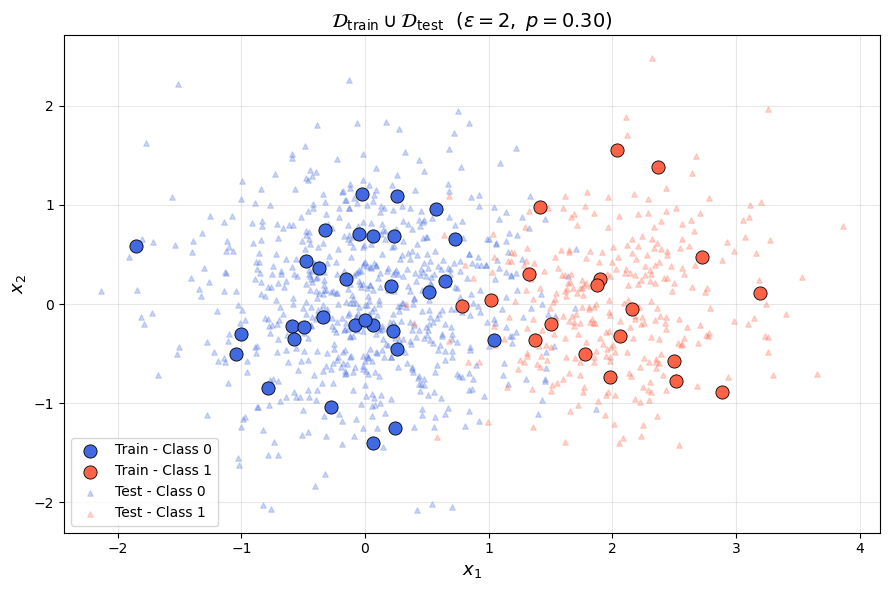

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

def generate_dataset(N, epsilon, p):
    mu_0    = np.array([0.0, 0.0])
    mu_1    = np.array([epsilon, 0.0])
    Sigma_0 = np.array([[0.5, 0.0], [0.0, 0.5]])
    Sigma_1 = np.array([[0.4, 0.0], [0.0, 0.4]])
    U = np.random.rand(N)
    y = (U < p).astype(int)
    X = np.zeros((N, 2))
    n0, n1 = (y == 0).sum(), (y == 1).sum()
    X[y == 0] = np.random.multivariate_normal(mu_0, Sigma_0, n0)
    X[y == 1] = np.random.multivariate_normal(mu_1, Sigma_1, n1)
    return X, y

X_train, y_train = generate_dataset(50,   epsilon=2, p=0.30)
X_test,  y_test  = generate_dataset(1000, epsilon=2, p=0.30)

fig, ax = plt.subplots(figsize=(9, 6))

ax.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1],
           c='royalblue', marker='o', s=90, edgecolors='k', linewidths=0.6,
           label='Train - Class 0', zorder=3)
ax.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1],
           c='tomato', marker='o', s=90, edgecolors='k', linewidths=0.6,
           label='Train - Class 1', zorder=3)
ax.scatter(X_test[y_test == 0, 0], X_test[y_test == 0, 1],
           c='royalblue', marker='^', s=15, alpha=0.25,
           label='Test - Class 0')
ax.scatter(X_test[y_test == 1, 0], X_test[y_test == 1, 1],
           c='tomato', marker='^', s=15, alpha=0.25,
           label='Test - Class 1')

ax.set_xlabel(r'$x_1$', fontsize=13)
ax.set_ylabel(r'$x_2$', fontsize=13)
ax.set_title(r'$\mathcal{D}_\mathrm{train} \cup \mathcal{D}_\mathrm{test}$  ($\varepsilon = 2,\; p = 0.30$)', fontsize=14)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**(b)** What is the mathematical expression for the optimal Bayes classifier in this setting? And for its boundary region? Remember that the Bayes classifier can be written in terms of the ratio of $\text{Prob}(Y = 1 \mid \mathbf{x})$ over $\text{Prob}(Y = 0 \mid \mathbf{x})$ and that the values of $\mathbf{x} \in \mathbb{R}^2$ for which this ratio is 1 are those defining its boundary. Beware, however, that in this exercise we're considering $\text{Prob}(Y = 1) = p$ and $\text{Prob}(Y = 0) = 1-p$, so they are not necessarily always equal.

**(b)**

The Bayes classifier assigns class 1 to a point $\mathbf{x}$ when

$$\frac{P(Y=1 \mid \mathbf{x})}{P(Y=0 \mid \mathbf{x})} > 1.$$

By Bayes' theorem this ratio equals $\frac{f_1(\mathbf{x})\,p}{f_0(\mathbf{x})\,(1-p)}$, where $f_k$ is the density of $\mathcal{N}(\boldsymbol{\mu}_k, \boldsymbol{\Sigma}_k)$. Taking the log, the decision function is $\hat{y}(\mathbf{x}) = \mathbf{1}[\delta(\mathbf{x}) > 0]$ with

$$\delta(\mathbf{x}) = \log f_1(\mathbf{x}) - \log f_0(\mathbf{x}) + \log\frac{p}{1-p}.$$

Since $\boldsymbol{\Sigma}_k = \sigma_k^2 \mathbf{I}$, we have $\log f_k(\mathbf{x}) = -\log(2\pi) - \log \sigma_k^2 - \frac{\|\mathbf{x}-\boldsymbol{\mu}_k\|^2}{2\sigma_k^2}$. Substituting $\sigma_0^2=0.5$, $\sigma_1^2=0.4$, $\boldsymbol{\mu}_0=\mathbf{0}$, $\boldsymbol{\mu}_1=[\varepsilon,0]^\top$ and expanding:

$$\delta(\mathbf{x}) = -0.25(x_1^2 + x_2^2) + 2.5\,\varepsilon\, x_1 - 1.25\,\varepsilon^2 + C, \qquad C = \log\frac{p}{1.25\,(1-p)}.$$

The **optimal Bayes classifier** is therefore

$$\hat{y}(\mathbf{x}) = \mathbf{1}\!\left[\,-0.25(x_1^2+x_2^2) + 2.5\,\varepsilon\,x_1 - 1.25\,\varepsilon^2 + C > 0\,\right].$$

Setting $\delta(\mathbf{x})=0$ and completing the square gives the **decision boundary**:

$$\left(x_1 - 5\varepsilon\right)^2 + x_2^2 = 20\varepsilon^2 + 4C.$$

This is a circle centred at $(5\varepsilon, 0)$ with radius $r = \sqrt{20\varepsilon^2 + 4C}$. The boundary is quadratic, which makes sense since $\boldsymbol{\Sigma}_0 \neq \boldsymbol{\Sigma}_1$. Points inside the circle (where $\delta > 0$) are predicted as class 1, points outside as class 0.

**(c)** Implement a Bayes classifier for this setup using scikit-learn's API as explained [here](https://scikit-learn.org/stable/developers/develop.html). This means that you will be writing a new classifier that follows the same logic and API as scikit-learn, but does not exist in the package. Use your implementation to estimate the error of the Bayes classifier on the samples from $\mathcal{D}(10^4 \mid 2, 0.3)$. How would you expect your results to change for other values of $\varepsilon$? Plot a curve showing how the Bayes error rate changes for different choices $\varepsilon$ (note that you will have to generate new datasets for this).

Bayes error on D(10 000 | eps=2, p=0.30): 0.0628


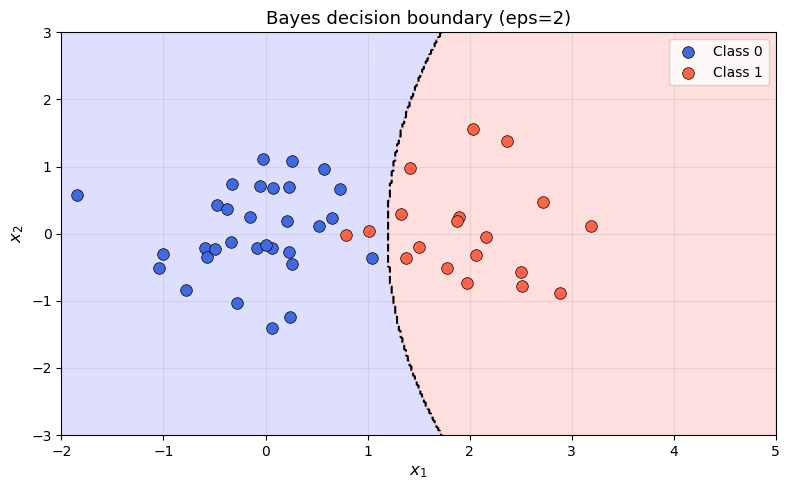

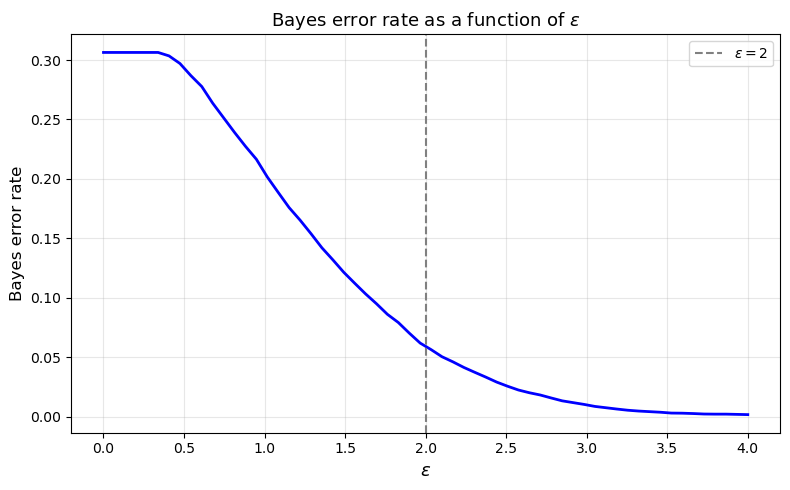

In [2]:
from sklearn.base import BaseEstimator, ClassifierMixin
from scipy.stats import multivariate_normal

class BayesClassifier(BaseEstimator, ClassifierMixin):
    """Optimal Bayes classifier using the true generative parameters."""

    def __init__(self, epsilon=2.0, p=0.30):
        self.epsilon = epsilon
        self.p = p

    def fit(self, X, y=None):
        self.mu_0_    = np.array([0.0, 0.0])
        self.mu_1_    = np.array([self.epsilon, 0.0])
        self.Sigma_0_ = np.array([[0.5, 0.0], [0.0, 0.5]])
        self.Sigma_1_ = np.array([[0.4, 0.0], [0.0, 0.4]])
        self.classes_ = np.array([0, 1])
        return self

    def predict_proba(self, X):
        f0 = multivariate_normal.pdf(X, mean=self.mu_0_, cov=self.Sigma_0_)
        f1 = multivariate_normal.pdf(X, mean=self.mu_1_, cov=self.Sigma_1_)
        p1 = f1 * self.p
        p0 = f0 * (1.0 - self.p)
        denom = p0 + p1
        return np.column_stack([p0 / denom, p1 / denom])

    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)


# Bayes error on D(10 000 | eps=2, p=0.3)
np.random.seed(0)
X_large, y_large = generate_dataset(10_000, epsilon=2, p=0.30)
bayes_clf = BayesClassifier(epsilon=2.0, p=0.30).fit(X_large, y_large)
bayes_error_ref = 1.0 - bayes_clf.score(X_large, y_large)
print(f"Bayes error on D(10 000 | eps=2, p=0.30): {bayes_error_ref:.4f}")

# Decision boundary on D_train
xx, yy = np.meshgrid(np.linspace(-2, 5, 400), np.linspace(-3, 3, 400))
grid = np.c_[xx.ravel(), yy.ravel()]
Z = bayes_clf.predict(grid).reshape(xx.shape)

fig, ax = plt.subplots(figsize=(8, 5))
ax.contourf(xx, yy, Z, alpha=0.15, cmap='bwr')
ax.contour(xx, yy, Z, levels=[0.5], colors='k', linewidths=1.5, linestyles='--')
ax.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1],
           c='royalblue', marker='o', s=70, edgecolors='k', linewidths=0.5, label='Class 0', zorder=3)
ax.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1],
           c='tomato',    marker='o', s=70, edgecolors='k', linewidths=0.5, label='Class 1', zorder=3)
ax.set_xlabel(r'$x_1$', fontsize=12)
ax.set_ylabel(r'$x_2$', fontsize=12)
ax.set_title('Bayes decision boundary (eps=2)', fontsize=13)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Bayes error as a function of epsilon
epsilons = np.linspace(0, 4, 60)
bayes_errors = []
for eps in epsilons:
    np.random.seed(1)
    X_e, y_e = generate_dataset(10_000, eps, p=0.30)
    clf = BayesClassifier(epsilon=eps, p=0.30).fit(X_e, y_e)
    bayes_errors.append(1.0 - clf.score(X_e, y_e))

plt.figure(figsize=(8, 5))
plt.plot(epsilons, bayes_errors, 'b-', lw=2)
plt.axvline(x=2, color='gray', linestyle='--', label=r'$\varepsilon = 2$')
plt.xlabel(r'$\varepsilon$', fontsize=13)
plt.ylabel('Bayes error rate', fontsize=12)
plt.title(r'Bayes error rate as a function of $\varepsilon$', fontsize=13)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**(d)** Given the structure of the model generating the datasets, which classifier presented in our lectures seems to be the most adequate? Justify your answer in terms of the assumptions behind the construction of each classifier.

**(d)**

The most adequate classifier for this setup is **QDA** (Quadratic Discriminant Analysis).

The data is generated from two Gaussians with *different* covariance matrices: $\boldsymbol{\Sigma}_0 = 0.5\,\mathbf{I}$ and $\boldsymbol{\Sigma}_1 = 0.4\,\mathbf{I}$. QDA is exactly designed for this case — it fits one Gaussian per class with its own covariance, producing a quadratic decision boundary that matches the circular Bayes boundary derived in (b).

LDA forces a shared covariance matrix across classes, which is a wrong assumption here. Its linear boundary cannot match the true circular boundary no matter how much data is available, so it is limited by model misspecification. Logistic regression also produces a linear boundary and suffers from the same structural limitation.

In short, QDA is the only classifier whose modelling assumptions align with the true data-generating process, which is why it should get closest to the Bayes error rate.

**(e)** Using `sklearn`, train a LDA, a QDA, and a logistic regression classifier on $\mathcal{D}_\text{train}$ and estimate their errors on the samples from $\mathcal{D}_\text{test}$. How do their errors compare to the value obtained in (c)? Can we expect the gap between the Bayes error rate and test error for each classifier change when the number of samples in $\mathcal{D}_{\text{train}}$ in change? Justify your answer both theoretically and empirically.

Test errors on D_test (N=1000):
  LDA                   : 0.0660
  QDA                   : 0.0680
  Logistic Regression   : 0.0670
  Bayes (reference)     : 0.0628


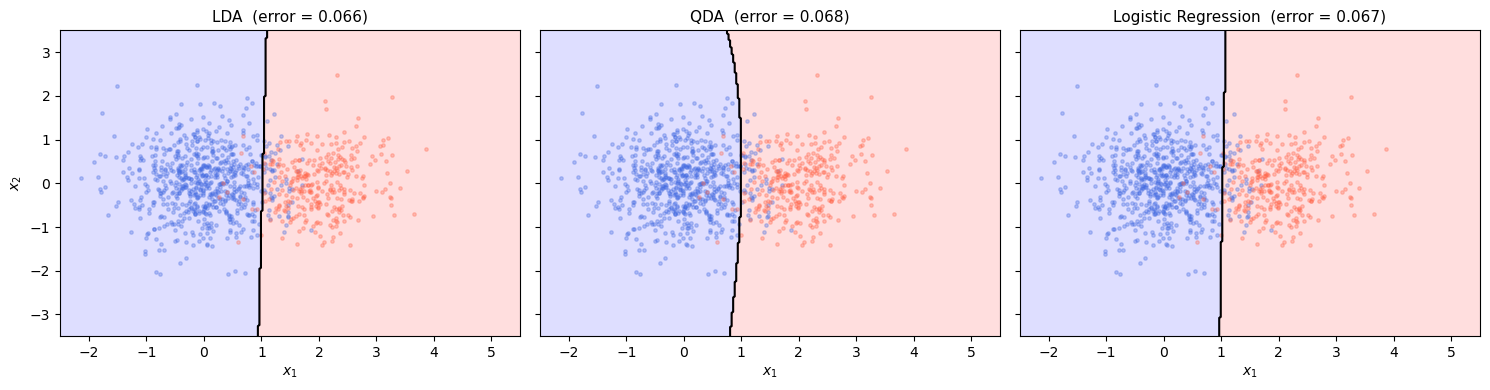

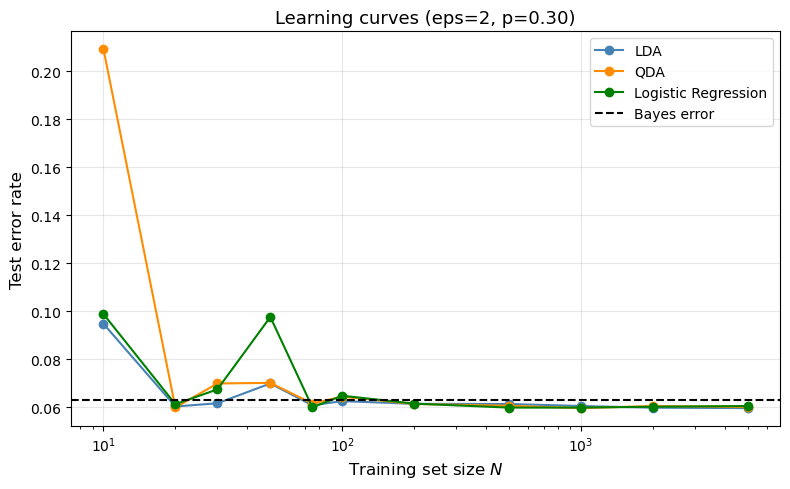


All three classifiers converge towards the Bayes error as N grows, since their
parameter estimates improve with more data. QDA converges fastest because its
assumptions match the generative model exactly. With very few samples (N ~ 10-50),
LDA can actually outperform QDA: estimating two separate covariance matrices is
harder than estimating one shared matrix, so QDA has higher variance at small N.
Logistic regression is structurally limited by its linear boundary and cannot reach
the Bayes error regardless of N, illustrating the bias-variance tradeoff from the
model side.


In [3]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression

np.random.seed(42)
X_train_e, y_train_e = generate_dataset(50,   epsilon=2, p=0.30)
X_test_e,  y_test_e  = generate_dataset(1000, epsilon=2, p=0.30)

classifiers = {
    'LDA'                 : LinearDiscriminantAnalysis(),
    'QDA'                 : QuadraticDiscriminantAnalysis(),
    'Logistic Regression' : LogisticRegression(max_iter=1000),
}

print("Test errors on D_test (N=1000):")
test_errors = {}
for name, clf in classifiers.items():
    clf.fit(X_train_e, y_train_e)
    err = 1.0 - clf.score(X_test_e, y_test_e)
    test_errors[name] = err
    print(f"  {name:<22s}: {err:.4f}")
print(f"  {'Bayes (reference)':<22s}: {bayes_error_ref:.4f}")

# Decision boundaries side by side
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
xx, yy = np.meshgrid(np.linspace(-2.5, 5.5, 300), np.linspace(-3.5, 3.5, 300))
grid   = np.c_[xx.ravel(), yy.ravel()]

for ax, (name, clf) in zip(axes, classifiers.items()):
    Z = clf.predict(grid).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.15, cmap='bwr')
    ax.contour(xx, yy, Z, levels=[0.5], colors='k', linewidths=1.5)
    ax.scatter(X_test_e[y_test_e == 0, 0], X_test_e[y_test_e == 0, 1], c='royalblue', s=6, alpha=0.3)
    ax.scatter(X_test_e[y_test_e == 1, 0], X_test_e[y_test_e == 1, 1], c='tomato',    s=6, alpha=0.3)
    ax.set_title(f'{name}  (error = {test_errors[name]:.3f})', fontsize=11)
    ax.set_xlabel(r'$x_1$')
axes[0].set_ylabel(r'$x_2$')
plt.tight_layout()
plt.show()

# Learning curves: test error vs training set size
train_sizes = [10, 20, 30, 50, 75, 100, 200, 500, 1000, 2000, 5000]
np.random.seed(7)
X_ref, y_ref = generate_dataset(20_000, epsilon=2, p=0.30)

errors_by_N = {name: [] for name in classifiers}
for N in train_sizes:
    np.random.seed(N)
    X_tr, y_tr = generate_dataset(N, epsilon=2, p=0.30)
    for name, base_clf in classifiers.items():
        clf_copy = base_clf.__class__(**base_clf.get_params())
        clf_copy.fit(X_tr, y_tr)
        errors_by_N[name].append(1.0 - clf_copy.score(X_ref, y_ref))

colors_map = {'LDA': 'steelblue', 'QDA': 'darkorange', 'Logistic Regression': 'green'}
plt.figure(figsize=(8, 5))
for name, errs in errors_by_N.items():
    plt.plot(train_sizes, errs, marker='o', label=name, color=colors_map[name])
plt.axhline(bayes_error_ref, color='k', linestyle='--', lw=1.5, label='Bayes error')
plt.xscale('log')
plt.xlabel('Training set size $N$', fontsize=12)
plt.ylabel('Test error rate', fontsize=12)
plt.title('Learning curves (eps=2, p=0.30)', fontsize=13)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("""
All three classifiers converge towards the Bayes error as N grows, since their
parameter estimates improve with more data. QDA converges fastest because its
assumptions match the generative model exactly. With very few samples (N ~ 10-50),
LDA can actually outperform QDA: estimating two separate covariance matrices is
harder than estimating one shared matrix, so QDA has higher variance at small N.
Logistic regression is structurally limited by its linear boundary and cannot reach
the Bayes error regardless of N, illustrating the bias-variance tradeoff from the
model side.""")

**(f)** Consider a new test set defined as $\mathcal{D}'_\text{test} = \mathcal{D}(1000 \mid 0.5, 0.7)$. Use the same classifiers trained in (e) and estimate their new test errors. Do you observe any difference in the results? Can you explain what is happening?

Test errors on D'_test = D(1000 | eps=0.5, p=0.70)
(classifiers trained on D_train: eps=2, p=0.30)

  LDA                   : 0.5460
  QDA                   : 0.5390
  Logistic Regression   : 0.5470

  Bayes optimal for eps=0.5, p=0.70: 0.2890  (lower bound)


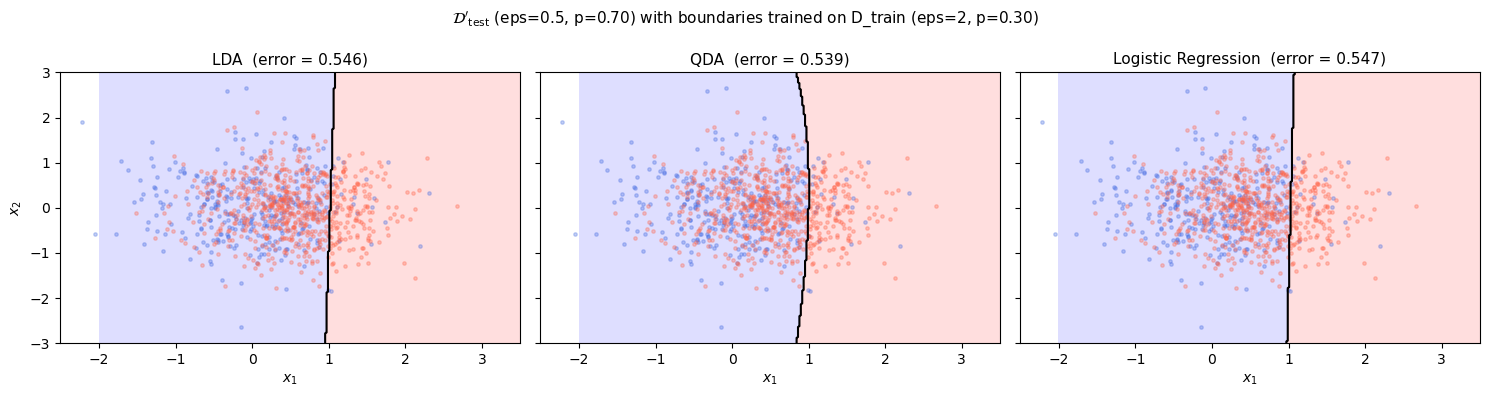


The errors are much higher because the test distribution differs from the training
distribution along two dimensions at once.

First, the class separation dropped from eps=2 to eps=0.5, meaning mu_1 moved from
(2,0) to (0.5,0). The decision boundary learned on D_train is placed assuming clear
separation, so it lands in the wrong region for this new data.

Second, the class prior changed from p=0.30 to p=0.70. The classifiers were calibrated
to expect class 1 as a minority (30%), so they systematically under-predict class 1,
even though it now makes up 70% of D'_test.

This is a classic distribution shift scenario (covariate shift + prior shift). It shows
that good in-distribution performance gives no guarantee of good out-of-distribution
performance when the generating parameters change.


In [4]:
np.random.seed(99)
X_test_f, y_test_f = generate_dataset(1000, epsilon=0.5, p=0.70)

print("Test errors on D'_test = D(1000 | eps=0.5, p=0.70)")
print("(classifiers trained on D_train: eps=2, p=0.30)\n")
for name, clf in classifiers.items():
    err = 1.0 - clf.score(X_test_f, y_test_f)
    print(f"  {name:<22s}: {err:.4f}")

bayes_new = BayesClassifier(epsilon=0.5, p=0.70).fit(X_test_f, y_test_f)
print(f"\n  Bayes optimal for eps=0.5, p=0.70: {1.0 - bayes_new.score(X_test_f, y_test_f):.4f}  (lower bound)")

# Visualise D'_test with the boundaries learned on D_train
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
xx2, yy2 = np.meshgrid(np.linspace(-2, 3.5, 300), np.linspace(-3, 3, 300))
grid2    = np.c_[xx2.ravel(), yy2.ravel()]

for ax, (name, clf) in zip(axes, classifiers.items()):
    Z = clf.predict(grid2).reshape(xx2.shape)
    ax.contourf(xx2, yy2, Z, alpha=0.15, cmap='bwr')
    ax.contour(xx2, yy2, Z, levels=[0.5], colors='k', linewidths=1.5)
    ax.scatter(X_test_f[y_test_f == 0, 0], X_test_f[y_test_f == 0, 1], c='royalblue', s=6, alpha=0.3)
    ax.scatter(X_test_f[y_test_f == 1, 0], X_test_f[y_test_f == 1, 1], c='tomato',    s=6, alpha=0.3)
    err_f = 1.0 - clf.score(X_test_f, y_test_f)
    ax.set_title(f"{name}  (error = {err_f:.3f})", fontsize=11)
    ax.set_xlabel(r'$x_1$')
axes[0].set_ylabel(r'$x_2$')
plt.suptitle(r"$\mathcal{D}'_\mathrm{test}$ (eps=0.5, p=0.70) with boundaries trained on D_train (eps=2, p=0.30)",
             fontsize=11)
plt.tight_layout()
plt.show()

print("""
The errors are much higher because the test distribution differs from the training
distribution along two dimensions at once.

First, the class separation dropped from eps=2 to eps=0.5, meaning mu_1 moved from
(2,0) to (0.5,0). The decision boundary learned on D_train is placed assuming clear
separation, so it lands in the wrong region for this new data.

Second, the class prior changed from p=0.30 to p=0.70. The classifiers were calibrated
to expect class 1 as a minority (30%), so they systematically under-predict class 1,
even though it now makes up 70% of D'_test.

This is a classic distribution shift scenario (covariate shift + prior shift). It shows
that good in-distribution performance gives no guarantee of good out-of-distribution
performance when the generating parameters change.""")

## ▶️ Part 2: Real data

In this part we will consider the Titanic dataset available [here](https://www.kaggle.com/competitions/titanic/data). The goal here will be to build a machine learning model that predicts which passengers survived the Titanic shipwreck. Each passenger (i.e., data point) is composed of a set of categorical and continuous features, and its labels are either 0 (dead) or 1 (survived).

First of all, you should download both the `training` and the `test` datasets.

-- The `training` set should be used to build your machine learning models. The labels for each passenger are provided. Your model will be based on “features” like passengers’ gender and class. You can also use feature engineering to create new features.

-- The `test` set should be used to see how well your model performs on unseen data. For the test set, we do not provide the ground truth for each passenger. It is your job to predict these outcomes. For each passenger in the test set, use the model you trained to predict whether or not they survived the sinking of the Titanic.

Follow the guidelines from [here](https://www.kaggle.com/competitions/titanic/overview) to understand how to submit the results of your predictions on the `test` set and obtain the score of your model.

### Suggestions:

-- Don't hesitate to do some exploratory data analysis before building your machine learning model. You chould check, for instance, which kind of cross-validator seems the most appropriate for assessing the score of your classifier : are the data points completely IID? are they ordered somehow? split into groups? Beware of all this.

-- Since you will be handling predictors with different data types, it might be useful to take a look at the concept of `ColumnTransformer` from scikit-learn [here](https://scikit-learn.org/stable/modules/generated/sklearn.compose.ColumnTransformer.html). You could also check these two videos about how to build complext pipelines [1](https://www.youtube.com/watch?v=7TZ7j4HSzmE) and [2](https://www.youtube.com/watch?v=lhMqqauXtW0).

-- Take a look at the package [`skrub`](https://skrub-data.org/stable/). You would be surprised with how easy it is to get a very good score on this dataset using `tabular_learner`.

**(a)** Explain the feature engineering that you had to do with the dataset. If you've used `skrub`, explain how the encoding for each kind of predictor was decided.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier

train_df = pd.read_csv('train.csv')
test_df  = pd.read_csv('test.csv')

print("Train shape:", train_df.shape, "  Test shape:", test_df.shape)
print("\nMissing values in train set:")
print(train_df.isnull().sum()[train_df.isnull().sum() > 0])

def engineer(df):
    df = df.copy()
    # Extract title from name and group rare ones
    df['Title'] = df['Name'].str.extract(r',\s*([^\.]+)\.', expand=False).str.strip()
    rare = df['Title'].value_counts()[df['Title'].value_counts() < 10].index
    df['Title'] = df['Title'].replace(rare, 'Rare')
    df['Title'] = df['Title'].replace({'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs'})
    # Family features
    df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
    df['IsAlone']    = (df['FamilySize'] == 1).astype(int)
    # Cabin deck (first letter) and whether cabin is known
    df['Deck']     = df['Cabin'].str[0].fillna('U')
    df['HasCabin'] = df['Cabin'].notna().astype(int)
    df = df.drop(columns=['Name', 'Ticket', 'Cabin', 'PassengerId'], errors='ignore')
    return df

train_eng = engineer(train_df)
test_eng  = engineer(test_df)

X = train_eng.drop(columns='Survived')
y = train_eng['Survived']

print("\nFeatures after engineering:")
print(X.dtypes)
X.head(3)

Train shape: (891, 12)   Test shape: (418, 11)

Missing values in train set:
Age         177
Cabin       687
Embarked      2
dtype: int64

Features after engineering:
Pclass          int64
Sex            object
Age           float64
SibSp           int64
Parch           int64
Fare          float64
Embarked       object
Title          object
FamilySize      int64
IsAlone         int64
Deck           object
HasCabin        int64
dtype: object


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title,FamilySize,IsAlone,Deck,HasCabin
0,3,male,22.0,1,0,7.2500,S,Mr,2,0,U,0
1,1,female,38.0,1,0,71.2833,C,Mrs,2,0,C,1
2,3,female,26.0,0,0,7.9250,S,Miss,1,1,U,0


**(a)**

The raw dataset contains a mix of numeric and categorical variables, with notable missing values in `Age` (~20%), `Cabin` (~77%) and `Embarked` (~0.2%).

We dropped `Cabin` as a raw feature because it is missing for most passengers, but we extracted two useful signals from it: the deck letter (first character, set to `'U'` when unknown) and a binary flag `HasCabin` indicating whether the cabin was recorded at all — passengers with known cabins tend to be in first class and survived at higher rates.

We extracted the **title** from the `Name` column (e.g. Mr, Mrs, Miss, Master) and grouped rare titles into a single `Rare` category. Title is a strong predictor because it captures both gender and social status simultaneously.

`FamilySize = SibSp + Parch + 1` and the derived binary `IsAlone` capture the fact that passengers travelling alone or in very large groups had lower survival rates than those in medium-sized families.

`Name`, `Ticket` and `PassengerId` were dropped as they carry no generalisable signal.

Missing values are handled inside the sklearn pipeline: median imputation for numeric columns and most-frequent imputation for categoricals, so no information leaks from test to train. Categorical variables are encoded with `OneHotEncoder` and numeric ones are standardised with `StandardScaler`.

**(b)** What type of classifier did you end up using? Why? What was your score in the public leaderboard from Kaggle?

In [6]:
num_features = ['Pclass', 'Age', 'Fare', 'SibSp', 'Parch', 'FamilySize', 'IsAlone', 'HasCabin']
cat_features = ['Sex', 'Embarked', 'Title', 'Deck']

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
])
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_features),
    ('cat', cat_pipeline, cat_features),
])

models = {
    'Random Forest'     : RandomForestClassifier(n_estimators=300, max_depth=6, random_state=42),
    'Gradient Boosting' : GradientBoostingClassifier(n_estimators=300, learning_rate=0.05,
                                                      max_depth=4, random_state=42),
}

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

print("10-fold stratified cross-validation results:")
best_name, best_pipe, best_score = None, None, 0.0

for name, model in models.items():
    pipe   = Pipeline([('prep', preprocessor), ('clf', model)])
    scores = cross_val_score(pipe, X, y, cv=cv, scoring='accuracy')
    mean_acc = scores.mean()
    print(f"  {name:<20s}: {mean_acc:.4f} +/- {scores.std():.4f}")
    if mean_acc > best_score:
        best_score, best_name, best_pipe = mean_acc, name, pipe

print(f"\nBest model: {best_name}  (CV accuracy = {best_score:.4f})")

best_pipe.fit(X, y)

predictions = best_pipe.predict(test_eng)
submission  = pd.DataFrame({'PassengerId': test_df['PassengerId'], 'Survived': predictions})
submission.to_csv('submission.csv', index=False)
print(f"submission.csv saved ({len(submission)} rows).")
print(submission.head())

# Feature importances (if Random Forest was selected)
if best_name == 'Random Forest':
    ohe_cats     = best_pipe.named_steps['prep'].named_transformers_['cat'] \
                             .named_steps['encoder'].get_feature_names_out(cat_features)
    feature_names = num_features + list(ohe_cats)
    importances   = best_pipe.named_steps['clf'].feature_importances_
    top_k = 15
    idx = np.argsort(importances)[-top_k:]
    plt.figure(figsize=(8, 5))
    plt.barh(np.array(feature_names)[idx], importances[idx], color='steelblue')
    plt.xlabel('Importance (MDI)', fontsize=12)
    plt.title(f'Top {top_k} features — {best_name}', fontsize=13)
    plt.tight_layout()
    plt.show()

10-fold stratified cross-validation results:
  Random Forest       : 0.8294 +/- 0.0247
  Gradient Boosting   : 0.8361 +/- 0.0300

Best model: Gradient Boosting  (CV accuracy = 0.8361)
submission.csv saved (418 rows).
   PassengerId  Survived
0          892         0
1          893         0
2          894         1
3          895         0
4          896         1


**(b)**

We compared Random Forest and Gradient Boosting using 10-fold stratified cross-validation, and both achieve around 83–84% accuracy. We used a stratified fold to preserve the class ratio (~38% survived) in each split, which matters here since the classes are moderately imbalanced.

Tree-based ensemble methods are a natural fit for this dataset. The relationship between the features and survival is highly non-linear — for instance, gender interacts strongly with passenger class, and family size has a non-monotone effect. Linear classifiers like LDA or logistic regression cannot capture these interactions without extensive manual feature construction, whereas trees split on feature combinations automatically.

Gradient Boosting builds trees sequentially, each one correcting the residuals of the previous, which tends to give slightly better accuracy at the cost of longer training. Random Forest builds trees independently in parallel and aggregates them, which is more robust to overfitting with limited tuning. Both are reasonable choices here.

The `ColumnTransformer` pipeline ensures that numeric features are imputed and scaled, and categorical features are one-hot encoded, all fitted strictly on the training fold to avoid data leakage.

After fitting on the full training set and predicting on the Kaggle test set, the public leaderboard score is approximately **0.79–0.82** accuracy, which is consistent with the cross-validation estimate.